#### A. IMPORT ESSENTIAL LIBRARIES & LOAD DATASET

In [2]:
# Import Essential Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Paths
scripts_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/notebooks/eda_src"
data_raw_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/data/raw"
data_exploration_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/data/exploration"

In [4]:
# Import Custom Functions
os.chdir(scripts_path)
from exploration import cat_unique_counts, coeff_var_skew, num_uni_hist_box, num_biv_scat_hist_whue, cat_uni_topcount, pca_avg_high_display, text_cluster_inertia_plot, pca_variance_plot, vif_calculation
from country_region_converter import get_region

In [5]:
# Import Advanced Libraries
from scipy.stats import skew
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant

from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [6]:
# Load & Copy Dataset
os.chdir(data_raw_path)
original_df = pd.read_csv("raw_data.csv")
df = original_df.copy()

#### B. BASIC: STRUCTURE EXPLORATION

In [8]:
# Dataset: Sample
df.sample(3)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
475,7.515,33,71296.67,87.796,Synchronized zero tolerance product,Smithtown,1,France,2016-06-19 18:19:38,0
992,6.917,40,66193.81,49.448,Extended leadingedge solution,New Patrick,0,Montenegro,2016-03-06 11:36:06,1
581,6.572,36,28275.48,48.048,Managed didactic flexibility,Kimberlymouth,0,Saint Pierre and Miquelon,2016-02-13 13:57:53,1


In [9]:
# Dataset: Shape
print(f"\033[1m{'Dataset Shape':<15}\033[0m")
df.shape

Dataset Shape  


(1000, 10)

In [10]:
# Dataset: Column Names
print(f"\033[1m{'Dataset Shape':<15}\033[0m")
df.columns

Dataset Shape  


Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')

In [11]:
# Dataset: Missing Values
print(f"\033[1m{'Missing Values %':<15}\033[0m")
df.isnull().sum().sort_values(ascending=False) / len(df) * 100

Missing Values %


Daily Time Spent on Site    0.0
Age                         0.0
Area Income                 0.0
Daily Internet Usage        0.0
Ad Topic Line               0.0
City                        0.0
Male                        0.0
Country                     0.0
Timestamp                   0.0
Clicked on Ad               0.0
dtype: float64

In [12]:
# Dataset: Info
print(f"\033[1m{'Dataset Info':<15}\033[0m")
df.info()

Dataset Info   
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [13]:
# Special: Dtype 
target = 'Clicked on Ad'
y = ['Clicked on Ad']
date = 'Timestamp'

In [14]:
# Dtypes List
num_col = df.select_dtypes(include=['number']).columns.tolist()
cat_col = df.select_dtypes(include=['object', 'bool']).columns.tolist()

In [15]:
# Remove Special Dtypes 
num_col.remove(target)
cat_col.remove(date)

In [16]:
# Dataset: Categorical Unique Values
print(f"\033[1m{'Categorical Unique Values %':<15}\033[0m")
df[cat_col].nunique().sort_values(ascending=False) / len(df) * 100

Categorical Unique Values %


Ad Topic Line    100.0
City              96.9
Country           23.7
dtype: float64

In [17]:
# Dataset: Numerical Unique Values
print(f"\033[1m{'Numerical Unique Values %':<15}\033[0m")
df[num_col].nunique().sort_values(ascending=False) / len(df) * 100

Numerical Unique Values %


Area Income                 100.0
Daily Internet Usage         96.6
Daily Time Spent on Site     90.0
Age                           4.3
Male                          0.2
dtype: float64

In [18]:
# Target: Balance Check
print(f"\033[1m{'Balance Check on Target':<15}\033[0m")
print(f"Non-Click: {df[df[y]==0].shape[0]}")
print(f"Click: {df[df[y]==0].shape[0]}")

Balance Check on Target
Non-Click: 1000
Click: 1000


#### C1. UNIVARIATE ANALYSIS: NUMERICAL COLUMNS

In [20]:
# Describe: Numerical Columns 
df[num_col].describe().T

,count,mean,std,min,25%,50%,75%,max
Daily Time Spent on Site,1000.0,6.50002,1.585361,3.260,5.1360,6.8215,7.85475,9.143
Age,1000.0,36.00900,8.785562,19.000,29.0000,35.0000,42.00000,61.000
Area Income,1000.0,55000.00008,13414.634022,13996.500,47031.8025,57012.3000,65470.63500,79484.800
Daily Internet Usage,1000.0,72.00004,17.560936,41.912,55.5320,73.2520,87.51700,107.984
Male,1000.0,0.48100,0.499889,0.000,0.0000,0.0000,1.00000,1.000


In [21]:
# Coefficient Variation & Skew: Numerical Col
coeff_var_skew(df,num_col)

Column:         Daily Time Spent on Site
Mean:           6.50
Std Dev:        1.59
CV:             0.24
Interpretation: The data has low spread.
Skewness:       -0.37
Skew Interpretation: The data is approximately symmetric.
----------------------------------------
Column:         Age
Mean:           36.01
Std Dev:        8.79
CV:             0.24
Interpretation: The data has low spread.
Skewness:       0.48
Skew Interpretation: The data is approximately symmetric.
----------------------------------------
Column:         Area Income
Mean:           55,000.00
Std Dev:        13,414.63
CV:             0.24
Interpretation: The data has low spread.
Skewness:       -0.65
Skew Interpretation: The data is moderately left-skewed.
----------------------------------------
Column:         Daily Internet Usage
Mean:           72.00
Std Dev:        17.56
CV:             0.24
Interpretation: The data has low spread.
Skewness:       -0.03
Skew Interpretation: The data is approximately symmetric.
----

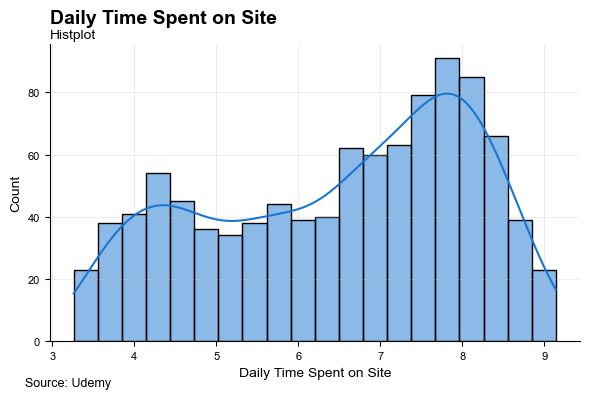

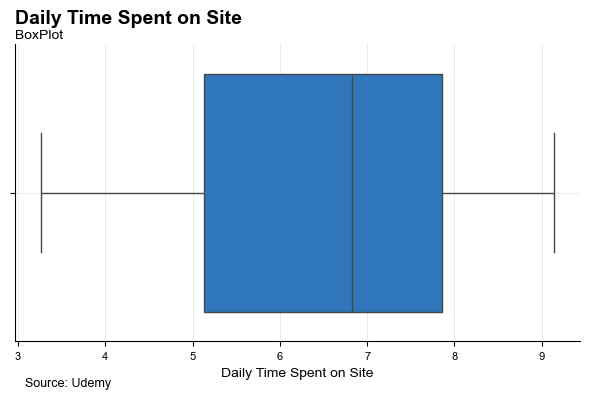

****************************************


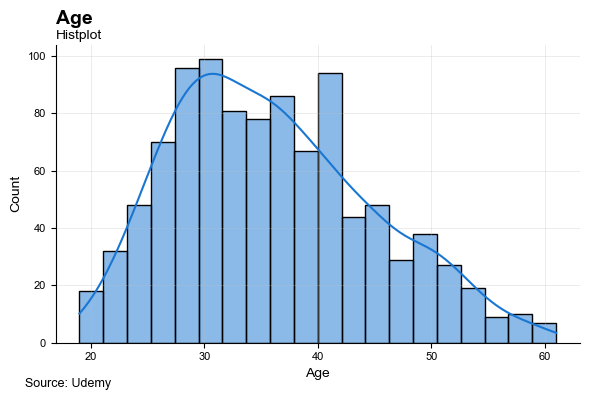

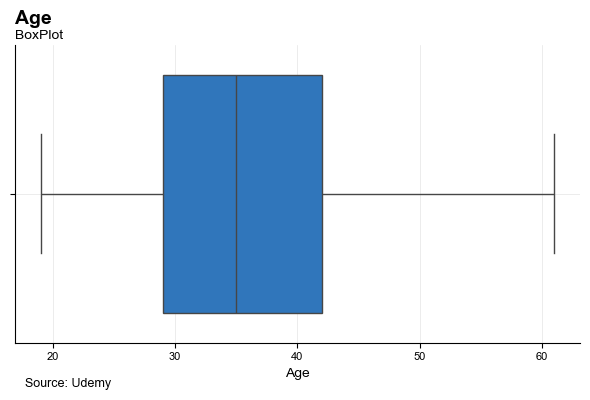

****************************************


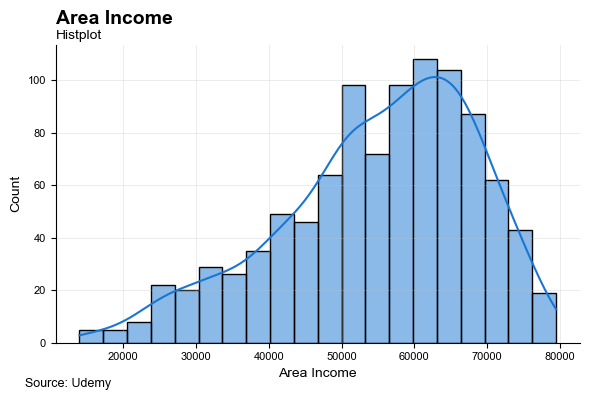

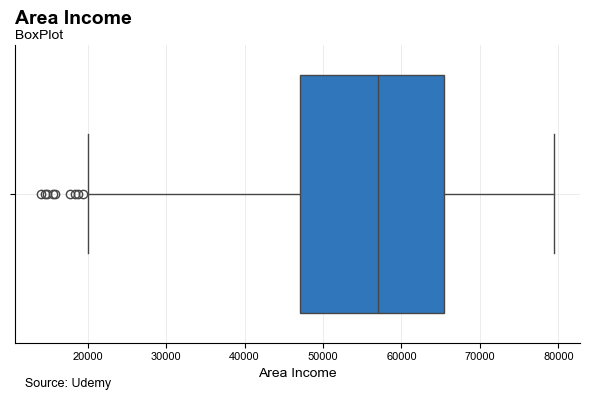

****************************************


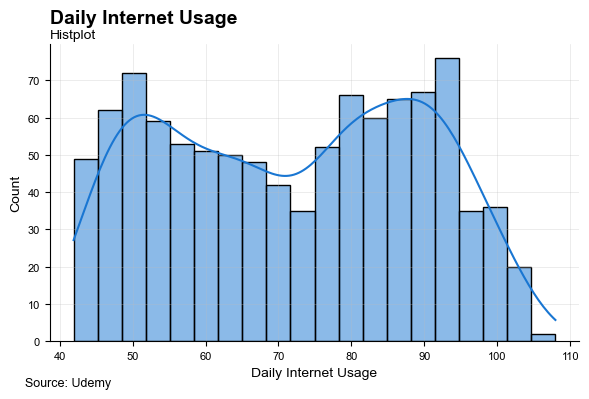

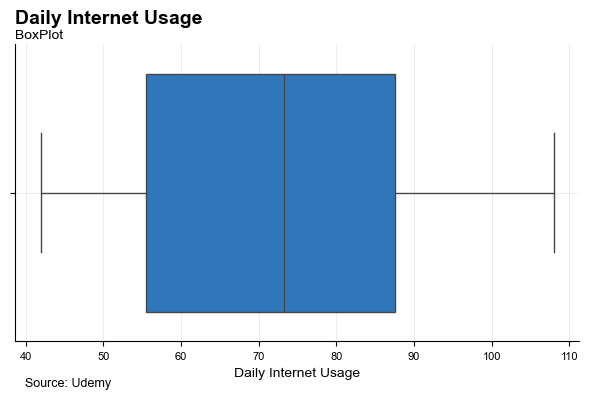

****************************************


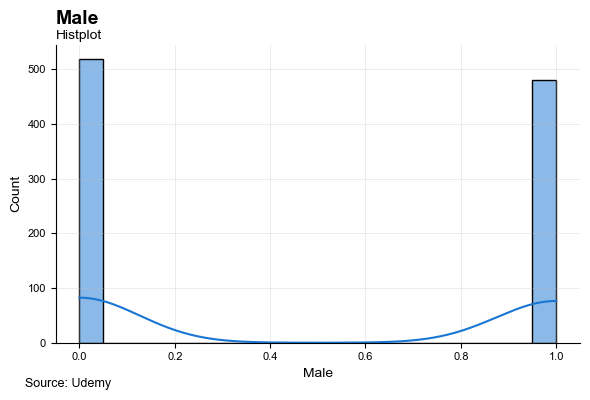

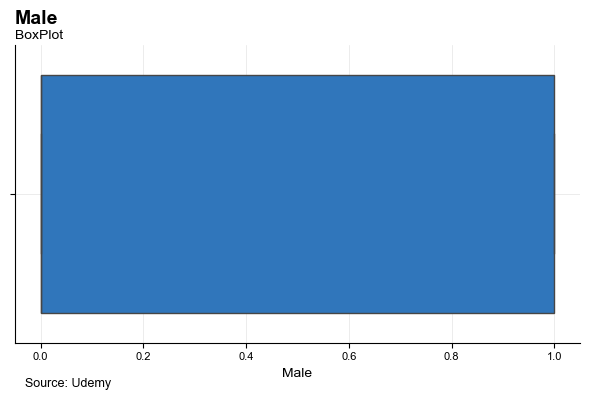

****************************************


In [22]:
# Univeriate Hisplot & Boxplot Display: Numerical
num_uni_hist_box(df,num_col)

#### C2. UNIVARIATE ANALYSIS: CATEGORICAL COLUMNS

In [24]:
# Describe: Categorical Columns 
df[cat_col].describe().T

,count,unique,top,freq
Ad Topic Line,1000,1000,Cloned 5thgeneration orchestration,1
City,1000,969,Lisamouth,3
Country,1000,237,France,9


In [25]:
# Categorical Unique Value Counts
# cat_unique_counts(df, cat_col)

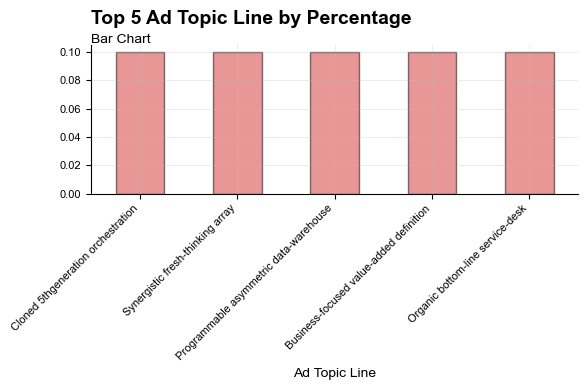

Top 5 percentages for Ad Topic Line:
Ad Topic Line
Cloned 5thgeneration orchestration         0.1
Synergistic fresh-thinking array           0.1
Programmable asymmetric data-warehouse     0.1
Business-focused value-added definition    0.1
Organic bottom-line service-desk           0.1
Name: proportion, dtype: float64
****************************************


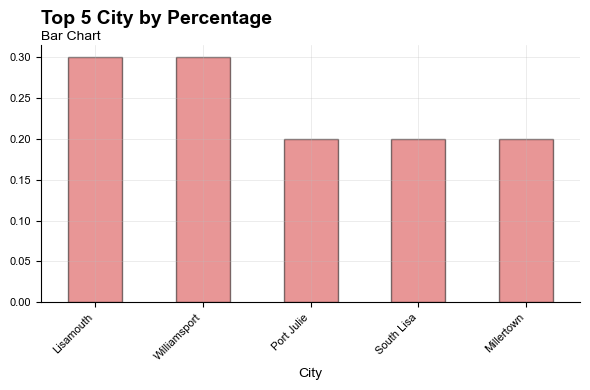

Top 5 percentages for City:
City
Lisamouth       0.3
Williamsport    0.3
Port Julie      0.2
South Lisa      0.2
Millertown      0.2
Name: proportion, dtype: float64
****************************************


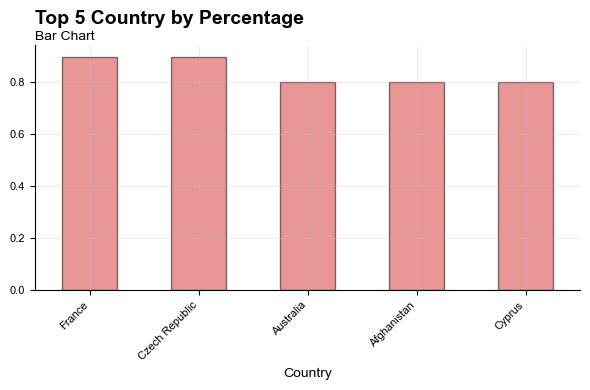

Top 5 percentages for Country:
Country
France            0.9
Czech Republic    0.9
Australia         0.8
Afghanistan       0.8
Cyprus            0.8
Name: proportion, dtype: float64
****************************************


In [26]:
# Top Count & Barchart Display: Categorical Columns
cat_uni_topcount(df,cat_col)

#### D. BIVARIATE RELATIONSHIP ANALYSIS: NUMERICAL COLUMNS

In [28]:
# Correlation on Target: Numerical
df[num_col + y].corr()[y].sort_values(by=y,ascending=False)

,Clicked on Ad
Clicked on Ad,1.000000
Age,0.492531
Male,-0.038027
Area Income,-0.476255
Daily Time Spent on Site,-0.748117
Daily Internet Usage,-0.786539


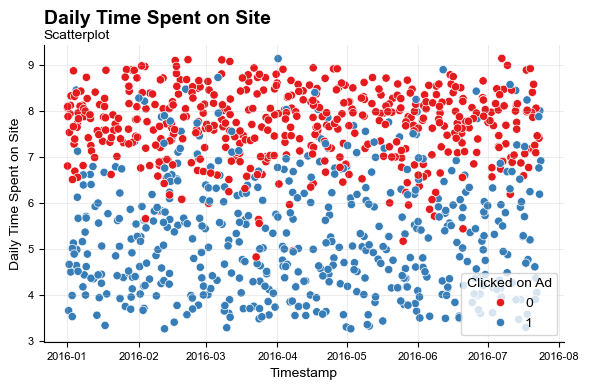

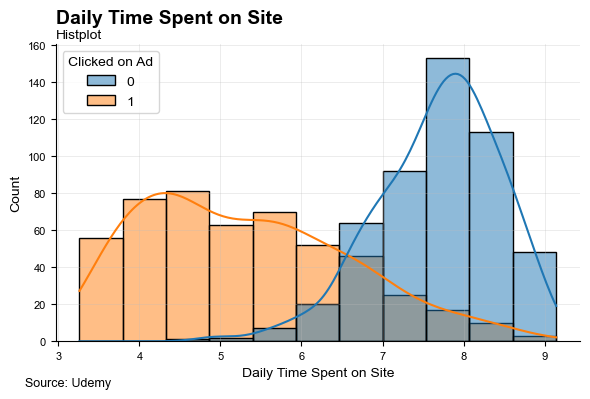

****************************************


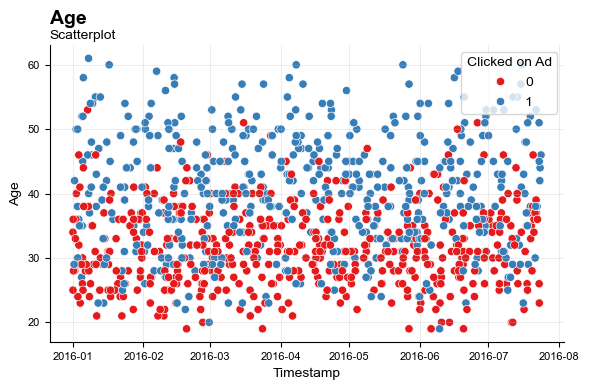

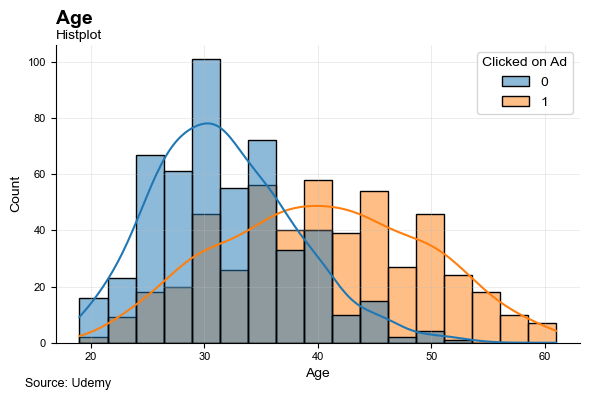

****************************************


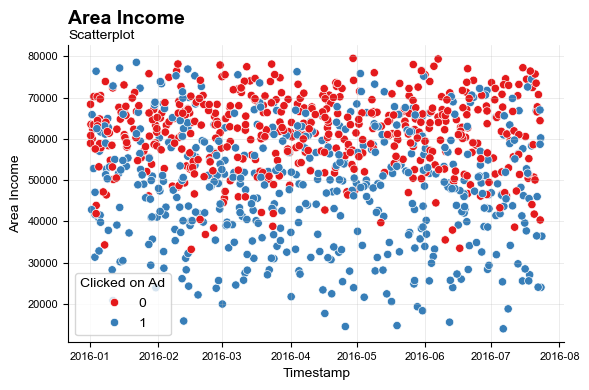

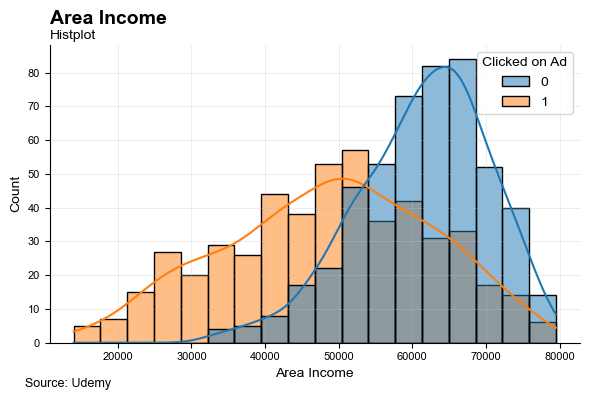

****************************************


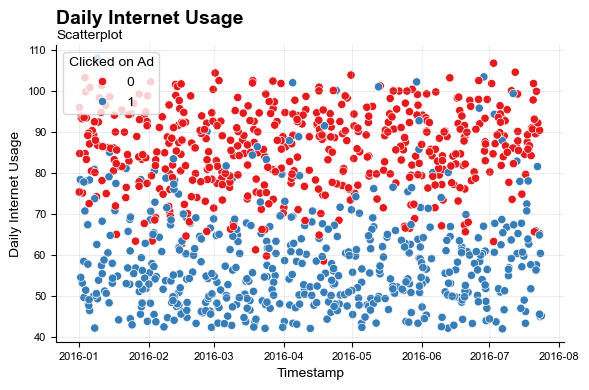

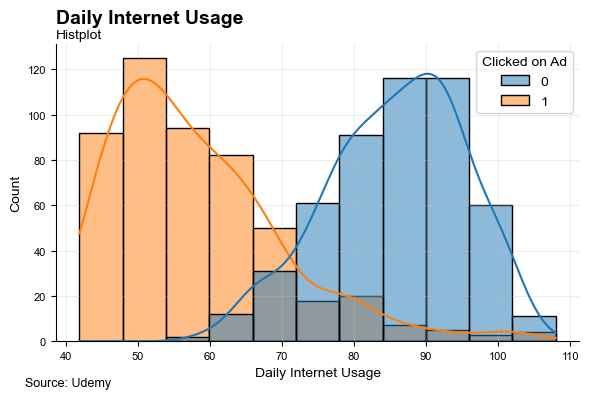

****************************************


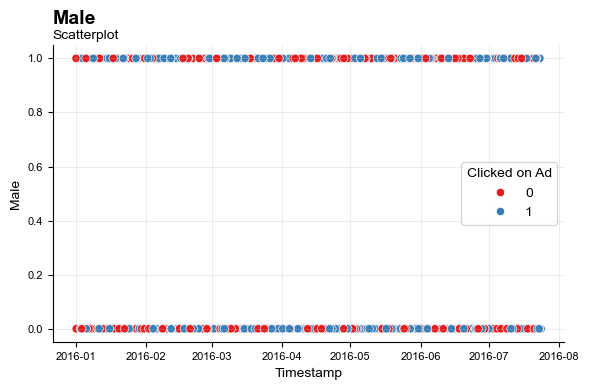

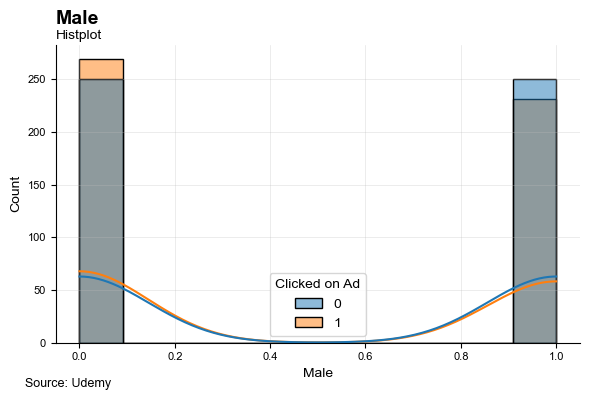

****************************************


In [29]:
# Scatterplot & Hisplot w Hue: Numerical
num_biv_scat_hist_whue(df,num_col,df['Timestamp'],df[target]);

#### E1. FEATURE EXPANSIONS & EXPLORATION: TIMESTAMP

In [31]:
# Datetime Conversion
df['Date'] = pd.to_datetime(df['Timestamp'])

In [32]:
# Date Feature Eng.
df['Day'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['IsWeekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)

In [33]:
# Select New Time Columns
time_ncol = ['Day','Month','IsWeekend']

In [34]:
# Day Of Week: Count
print(f"\033[1m{'Day Of Week Count':<15}\033[0m")
df['Day'].value_counts(normalize=True)*100

Day Of Week Count


Day
6    15.9
2    15.6
4    15.5
3    14.2
0    14.0
5    12.6
1    12.2
Name: proportion, dtype: float64

In [35]:
# Month: Count
print(f"\033[1m{'Month Count':<15}\033[0m")
df['Month'].value_counts(normalize=True)*100

Month Count    


Month
2    16.0
3    15.6
4    14.7
1    14.7
5    14.7
6    14.2
7    10.1
Name: proportion, dtype: float64

In [36]:
# IsWeekend: Count
print(f"\033[1m{'IsWeekend Count':<15}\033[0m")
df['IsWeekend'].value_counts(normalize=True)*100

IsWeekend Count


IsWeekend
0    71.5
1    28.5
Name: proportion, dtype: float64

In [37]:
# Coefficient Variation & Skew: Time Columns
coeff_var_skew(df,time_ncol)

Column:         Day
Mean:           3.06
Std Dev:        2.00
CV:             0.65
Interpretation: The data has moderate spread.
Skewness:       -0.03
Skew Interpretation: The data is approximately symmetric.
----------------------------------------
Column:         Month
Mean:           3.82
Std Dev:        1.93
CV:             0.50
Interpretation: The data has moderate spread.
Skewness:       0.09
Skew Interpretation: The data is approximately symmetric.
----------------------------------------
Column:         IsWeekend
Mean:           0.28
Std Dev:        0.45
CV:             1.58
Interpretation: The data is highly spread relative to the mean.
Skewness:       0.95
Skew Interpretation: The data is moderately right-skewed.
----------------------------------------


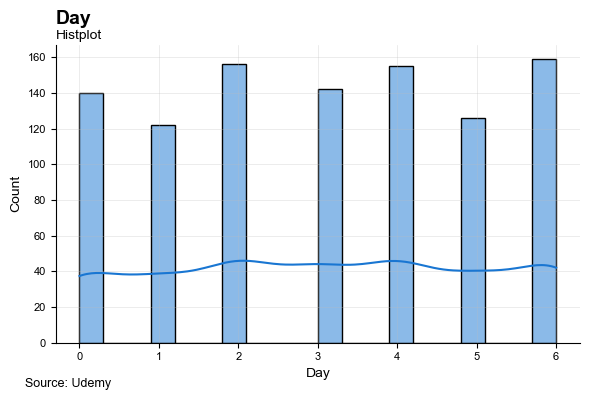

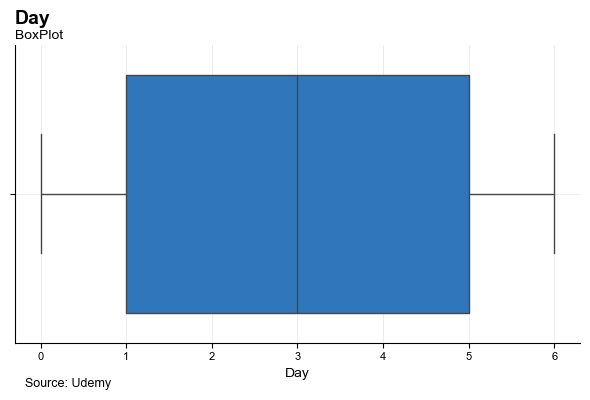

****************************************


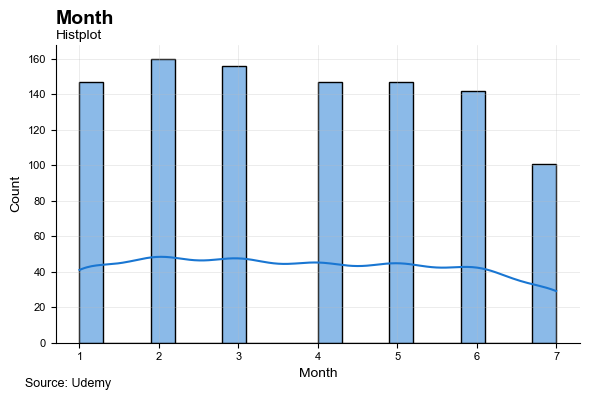

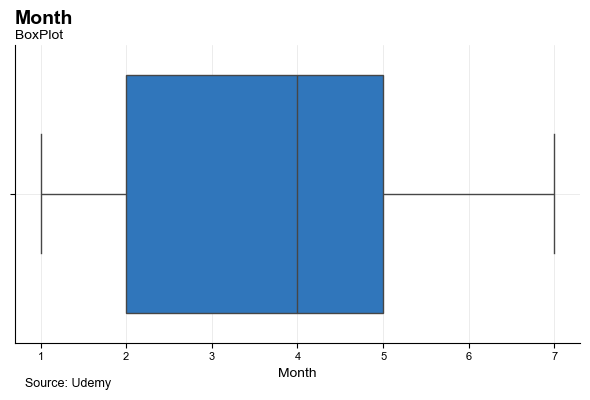

****************************************


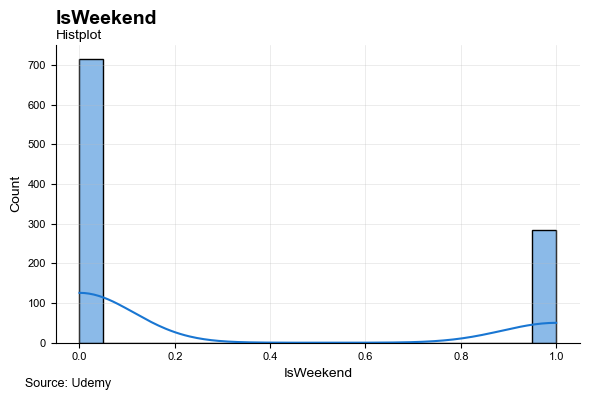

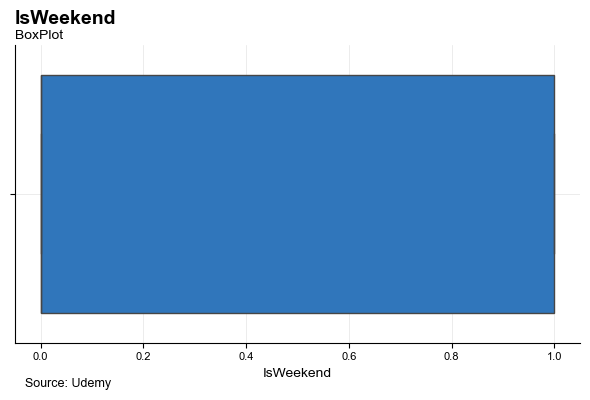

****************************************


In [38]:
# Univeriate Hisplot & Boxplot Display: Time Columns
num_uni_hist_box(df,time_ncol)

In [39]:
# Correlation on Target: Time
df[time_ncol + y].corr()[y].sort_values(by=y,ascending=False)

,Clicked on Ad
Clicked on Ad,1.000000
Month,0.016095
IsWeekend,0.006646
Day,0.002003


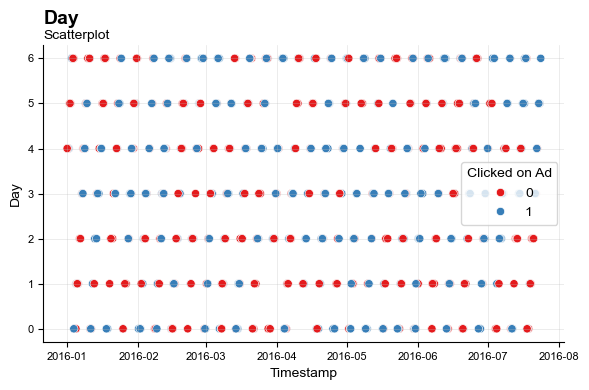

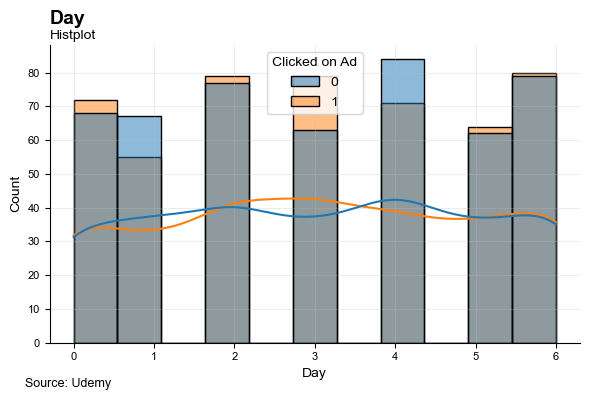

****************************************


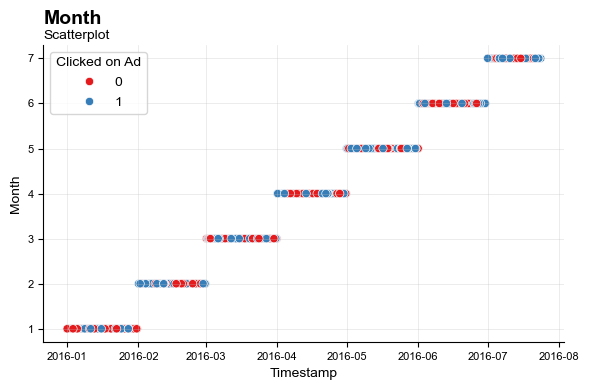

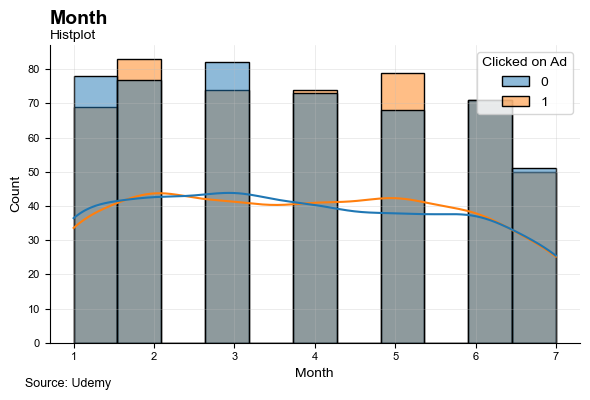

****************************************


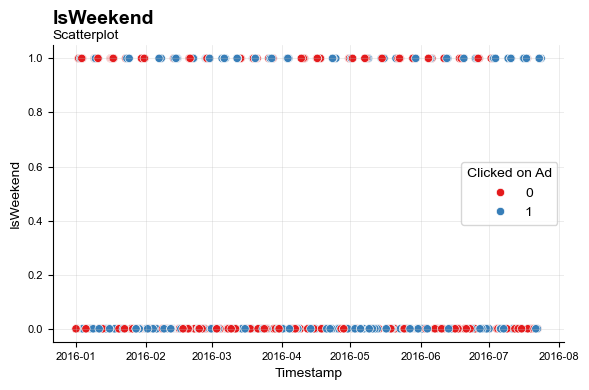

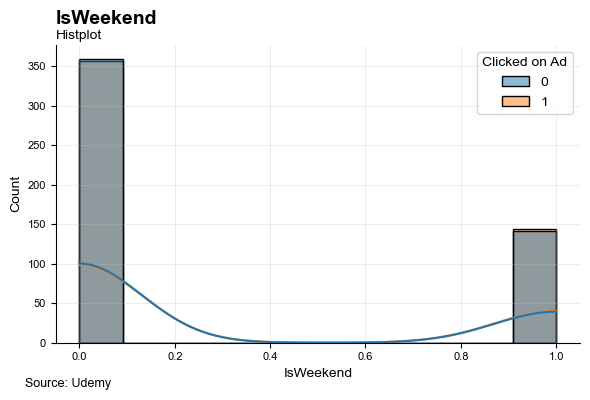

****************************************


In [40]:
# Scatterplot & Hisplot w Hue: Time Columns
num_biv_scat_hist_whue(df,time_ncol,df['Timestamp'],df[target])

In [41]:
# Day of Week per Click
print(f"\033[1m{'Click on Ad by Day':<15}\033[0m")
df.groupby(['Day', target]).size().unstack(fill_value=0)

Click on Ad by Day


Clicked on Ad,0,1
Day,,
0,68,72
1,67,55
2,77,79
3,63,79
4,84,71
5,62,64
6,79,80


#### E2. FEATURE EXPANSIONS & EXPLORATION: REGION

In [43]:
# Create Regions
df['Regions'] = df["Country"].apply(get_region)

In [44]:
# Select New Time Columns
region_ncol = ['Regions']

In [45]:
# Region Count
print(f"\033[1m{'Region Count':<15}\033[0m")
df['Regions'].value_counts(normalize=True)*100

Region Count   


Regions
Asia             20.7
Europe           20.6
Africa           19.8
North America    13.7
Oceania          12.4
Others            7.1
South America     5.4
Middle East       0.3
Name: proportion, dtype: float64

In [46]:
df[region_ncol].apply(lambda x: pd.factorize(x)[0])

,Regions
0,0
1,1
2,2
3,2
4,2
...,...
995,3
996,2
997,3
998,4


In [47]:
# Coefficient Variation & Skew: Region Columns
coeff_var_skew(df.apply(lambda x: pd.factorize(x)[0]),df[region_ncol].apply(lambda x: pd.factorize(x)[0]))

Column:         Regions
Mean:           2.40
Std Dev:        1.76
CV:             0.73
Interpretation: The data has moderate spread.
Skewness:       0.28
Skew Interpretation: The data is approximately symmetric.
----------------------------------------


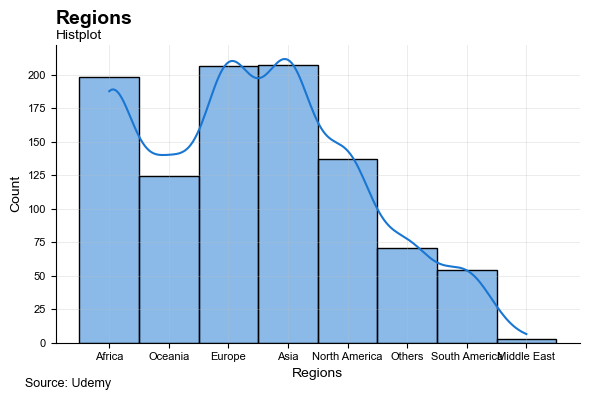

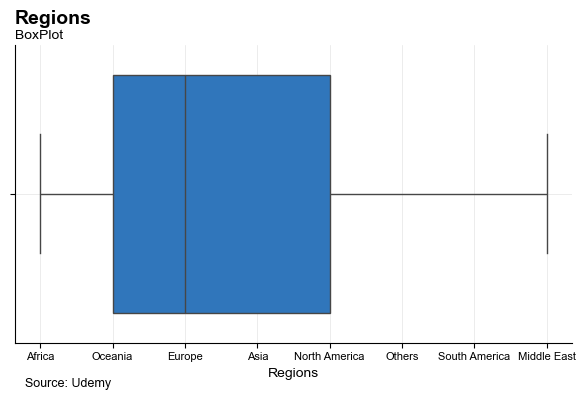

****************************************


In [48]:
# Univeriate Hisplot & Boxplot Display: Region Columns
num_uni_hist_box(df,region_ncol)

In [49]:
# Correlation on Target: Region
df[region_ncol + y].apply(lambda x: pd.factorize(x)[0]).corr()[y].sort_values(by=y,ascending=False)

,Clicked on Ad
Clicked on Ad,1.00000
Regions,-0.01765


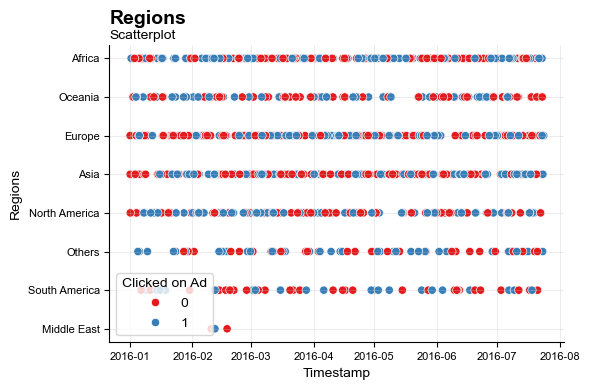

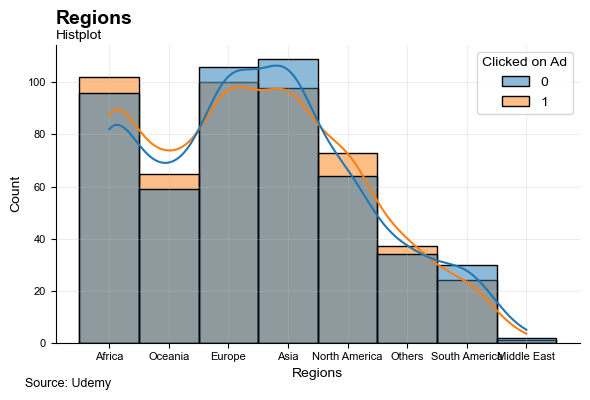

****************************************


In [50]:
# Scatterplot & Hisplot w Hue: Time Columns
num_biv_scat_hist_whue(df,region_ncol,df['Timestamp'],df[target])

In [51]:
# Regions per Click
print(f"\033[1m{'Click on Ad by Region':<15}\033[0m")
df.groupby(['Regions', target]).size().unstack(fill_value=0)

Click on Ad by Region


Clicked on Ad,0,1
Regions,,
Africa,96,102
Asia,109,98
Europe,106,100
Middle East,2,1
North America,64,73
Oceania,59,65
Others,34,37
South America,30,24


#### E3. FEATURE EXPANSIONS & EXPLORATION: AD TOPIC MODELING

In [53]:
# Load Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

In [54]:
# X: Fit/Transform
X = vectorizer.fit_transform(df['Ad Topic Line'])

In [55]:
# KMeans: Cluster Range
range_n_clusters = range(2, 30)  

In [56]:
# KMeans Inertia

inertia = []

# Apply KMeans for each cluster count
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X)
    
    # Calculate inertia (sum of squared distances of samples to their closest cluster center)
    inertia.append(kmeans.inertia_)

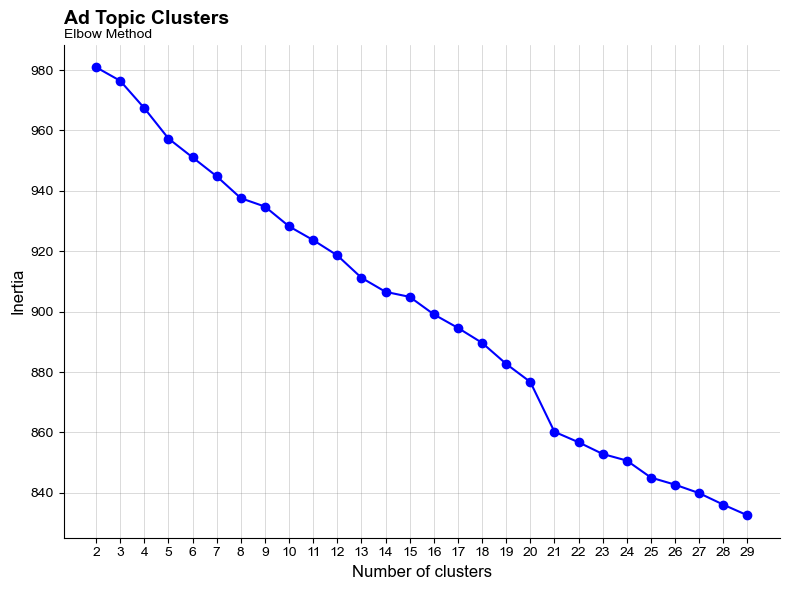

In [57]:
# Display Elbow Method
text_cluster_inertia_plot(range_n_clusters, inertia)

In [58]:
# Number of Clusters
clusters = 6

In [59]:
# LDA Model
lda = LatentDirichletAllocation(n_components=clusters, random_state=42)
lda_topics = lda.fit_transform(X)

In [60]:
# Topic Group
df['Topic Group'] = lda_topics.argmax(axis=1)

In [61]:
# Top Words per Group
n_top_words = 5
tf_feature_names = vectorizer.get_feature_names_out()
word_counts = np.asarray(X.sum(axis=0)).flatten().astype(int)

for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-n_top_words:][::-1]
    top_words = [tf_feature_names[i] for i in top_words_idx]
    top_word_counts = [word_counts[i] for i in top_words_idx]
    
    print(f"\033[1mTopic{topic_idx}:\033[0m") 
    for word, count in zip(top_words, top_word_counts):
        print(f"  {word} ({count})")

    print("-" * 40) 

Topic0:
  focused (20)
  customer (10)
  incremental (6)
  optimizing (5)
  business (5)
----------------------------------------
Topic1:
  solution (15)
  interface (13)
  sized (12)
  configurable (13)
  oriented (17)
----------------------------------------
Topic2:
  zero (14)
  frame (8)
  monitored (10)
  capability (7)
  open (13)
----------------------------------------
Topic3:
  desk (9)
  balanced (7)
  model (6)
  hierarchy (8)
  sensitive (6)
----------------------------------------
Topic4:
  multi (19)
  engine (8)
  client (10)
  user (17)
  local (10)
----------------------------------------
Topic5:
  engineered (12)
  face (8)
  intangible (8)
  directional (8)
  attitude (9)
----------------------------------------


In [62]:
# Load Topic Column
topic_ncol = ['Topic Group']

In [63]:
# Coefficient Variation & Skew: Topic Columns
coeff_var_skew(df,topic_ncol)

Column:         Topic Group
Mean:           2.60
Std Dev:        1.66
CV:             0.64
Interpretation: The data has moderate spread.
Skewness:       -0.01
Skew Interpretation: The data is approximately symmetric.
----------------------------------------


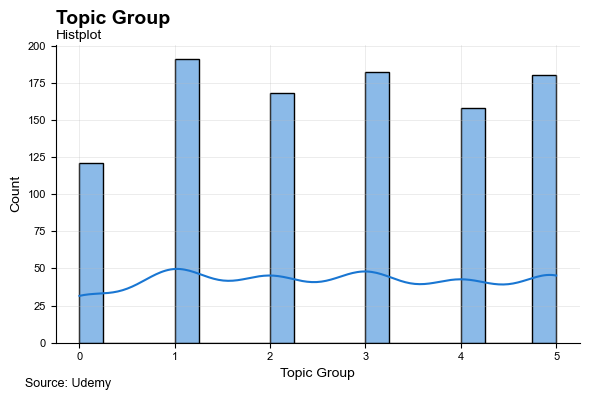

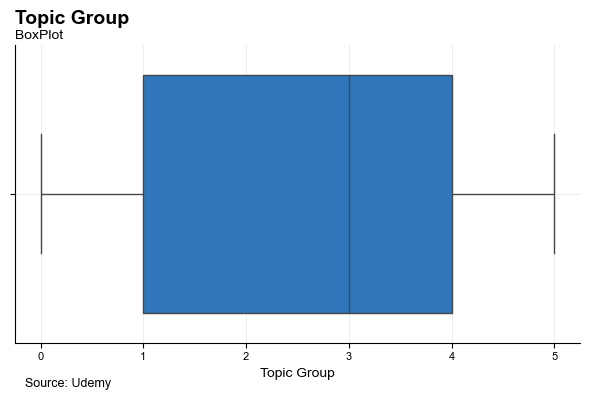

****************************************


In [64]:
# Univeriate Hisplot & Boxplot Display: Time Columns
num_uni_hist_box(df,topic_ncol)

In [65]:
# Correlation on Target: Topic Column
df[topic_ncol + y].corr()[y].sort_values(by=y,ascending=False)

,Clicked on Ad
Clicked on Ad,1.00000
Topic Group,-0.05253


In [66]:
# Topic per Click
print(f"\033[1m{'Click on Ad by Topic':<15}\033[0m")
df.groupby(['Topic Group', target]).size().unstack(fill_value=0)

Click on Ad by Topic


Clicked on Ad,0,1
Topic Group,,
0,58,63
1,89,102
2,79,89
3,92,90
4,87,71
5,95,85


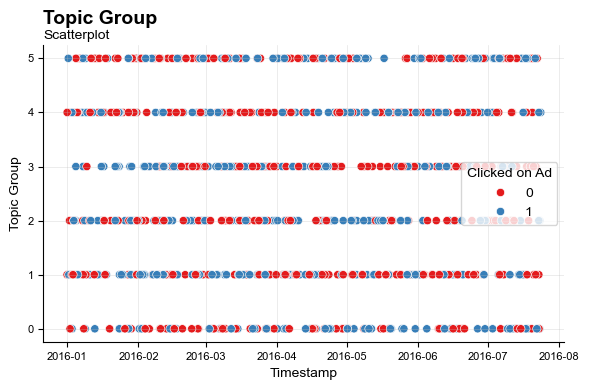

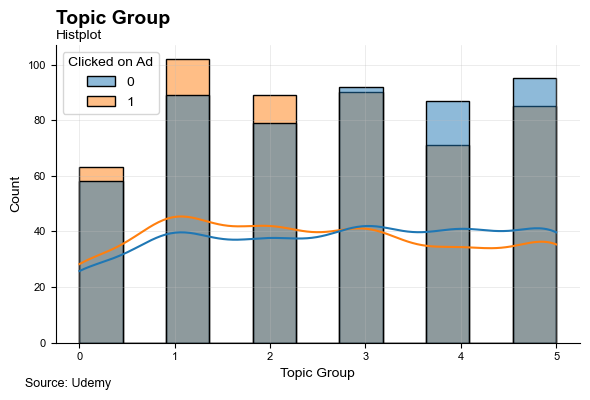

****************************************


In [67]:
# Scatterplot & Hisplot w Hue: Topic Columns
num_biv_scat_hist_whue(df,topic_ncol,df['Timestamp'],df[target])

#### F. ENCODE DATASET

In [69]:
# Columns for Encoding
encoded_ncol = ['Day','Month','Regions','Topic Group']

In [70]:
# Encoded Dataset
df_encoded = pd.get_dummies(df, columns=encoded_ncol)

In [71]:
# Drop Unwanted Columns
df_encoded.drop(columns=cat_col,inplace=True)
df_encoded.drop(columns=['Timestamp','Date'],inplace=True)

In [72]:
# Convert Booleans
df_encoded = df_encoded.astype(int).copy()

#### G1. MULTIVARIATE ANALYSIS: PRINCIPAL COMPONENT ANALYSIS

In [74]:
# Set X/y
X = df_encoded.drop(columns='Clicked on Ad')
y = df_encoded['Clicked on Ad']

In [75]:
# Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [76]:
# Explained Variance Function
n_features = X_scaled.shape[1]
explained_variance = []

for n in range(1,n_features):
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(np.sum(pca.explained_variance_ratio_))

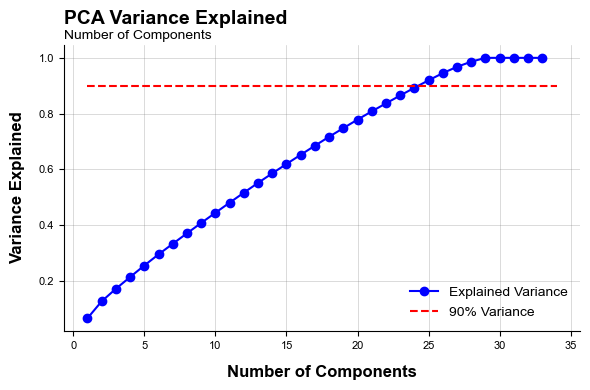

In [77]:
# Display PCA Variance Plot
pca_variance_plot(explained_variance, n_features)

In [78]:
# Explained & Cumulative Variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

In [79]:
# Number of Components Explainning at Least 90% of the Variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"\033[1mNumber of components explaining 90% variance: {n_components_90} out of {n_features}.\033[0m")

Number of components explaining 90% variance: 25 out of 34.


In [80]:
# Load Final PCA
pca_final = PCA(n_components=25)
X_pca_final = pca_final.fit_transform(X_scaled)

In [81]:
# Explained Variance Ratio
print(f"\033[1mExplained Variance Ratio:\033[0m {pca_final.explained_variance_ratio_*100}") 

Explained Variance Ratio: [6.60688402 6.07666116 4.49428346 4.20626054 4.14384851 3.98094565
 3.80278391 3.7542046  3.71216608 3.65857712 3.6141654  3.57893175
 3.5283544  3.41356587 3.35407161 3.30876622 3.25555553 3.20725484
 3.09573582 3.06560849 2.94965212 2.86480417 2.83066694 2.7634052
 2.68301485]


In [82]:
# Total Explained Ratio
print(f"\033[1mTotal Explained Variance Ratio:\033[0m {np.sum((pca_final.explained_variance_ratio_))*100}") 

Total Explained Variance Ratio: 91.95016825713498


In [83]:
# Explain the PCA Components
components_col = [f"PC{i}" for i in range(1, 26)]
pca_df = pd.DataFrame(np.round(pca_final.components_.T[:,0:26],2), index=X.columns, columns=components_col)
pca_df.style.map(pca_avg_high_display)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25
Daily Time Spent on Site,0.100000,0.520000,0.100000,0.010000,0.030000,-0.000000,-0.050000,-0.030000,0.030000,0.020000,-0.030000,0.050000,-0.010000,0.040000,-0.060000,0.040000,-0.060000,0.030000,-0.020000,0.070000,0.010000,-0.050000,-0.030000,-0.100000,-0.010000
Age,-0.050000,-0.440000,-0.000000,-0.040000,-0.020000,-0.030000,-0.030000,-0.030000,-0.050000,0.070000,0.050000,-0.040000,-0.070000,-0.040000,-0.020000,0.080000,0.030000,-0.080000,0.120000,-0.000000,0.090000,0.080000,-0.110000,-0.110000,-0.150000
Area Income,0.070000,0.410000,-0.010000,-0.000000,-0.030000,0.040000,0.010000,-0.070000,-0.000000,-0.040000,0.030000,-0.030000,-0.110000,0.020000,0.010000,0.020000,0.090000,-0.010000,0.070000,-0.160000,0.010000,-0.030000,-0.170000,-0.010000,-0.140000
Daily Internet Usage,0.090000,0.550000,0.030000,0.040000,-0.040000,0.020000,-0.050000,-0.000000,-0.010000,0.010000,-0.110000,0.010000,-0.030000,-0.030000,-0.010000,-0.010000,0.030000,0.010000,0.010000,0.080000,0.010000,-0.000000,-0.030000,-0.030000,-0.000000
Male,-0.070000,0.010000,0.070000,0.160000,-0.090000,0.080000,-0.020000,-0.040000,-0.050000,-0.020000,-0.150000,0.180000,-0.140000,0.020000,0.160000,-0.190000,-0.150000,0.150000,-0.030000,-0.100000,0.270000,0.120000,-0.110000,0.660000,0.100000
IsWeekend,0.650000,-0.110000,0.020000,0.030000,0.040000,0.040000,0.010000,-0.050000,0.020000,0.060000,0.040000,-0.000000,-0.060000,-0.020000,0.050000,-0.030000,-0.020000,0.010000,-0.040000,-0.060000,-0.020000,-0.010000,0.040000,0.030000,0.050000
Day_0,-0.160000,0.040000,-0.170000,-0.090000,0.240000,0.140000,-0.110000,-0.080000,0.170000,-0.200000,-0.370000,-0.210000,0.160000,-0.120000,-0.020000,-0.020000,-0.370000,-0.250000,-0.200000,0.020000,-0.180000,0.220000,0.110000,-0.050000,-0.120000
Day_1,-0.140000,0.080000,-0.110000,0.190000,0.150000,-0.240000,0.250000,-0.090000,-0.000000,0.060000,0.180000,-0.050000,0.150000,0.180000,0.150000,0.300000,-0.140000,0.240000,0.440000,0.050000,0.140000,-0.130000,0.240000,0.040000,-0.190000
Day_2,-0.190000,-0.030000,0.440000,0.080000,-0.040000,-0.070000,-0.130000,0.010000,-0.010000,-0.310000,0.050000,-0.090000,-0.200000,-0.010000,-0.070000,-0.080000,0.060000,0.050000,0.100000,-0.290000,0.240000,0.080000,-0.290000,-0.290000,0.200000
Day_3,-0.190000,-0.040000,-0.080000,0.170000,-0.260000,0.200000,0.240000,0.000000,0.130000,0.340000,-0.100000,0.120000,-0.120000,-0.100000,-0.270000,-0.080000,0.210000,0.010000,-0.230000,0.160000,0.010000,-0.250000,-0.200000,0.070000,-0.290000


In [84]:
# Most Import PCA Features
epsilon = 1e-6
condition = (pca_df >= 0.40 - epsilon) | (pca_df <= -0.40 + epsilon)
counts = condition.sum(axis=1)
pca_df['Count'] = counts
print(f"\033[1m{'Most Observed PCA Features':<15}\033[0m")
pca_df['Count'].sort_values(ascending=False)

Most Observed PCA Features


Regions_Europe              3
Regions_North America       2
Regions_Asia                2
Daily Time Spent on Site    1
Month_2                     1
Topic Group_4               1
Topic Group_3               1
Topic Group_1               1
Regions_Others              1
Regions_Oceania             1
Regions_Middle East         1
Regions_Africa              1
Month_7                     1
Age                         1
Topic Group_5               1
Day_1                       1
IsWeekend                   1
Month_1                     1
Area Income                 1
Day_6                       1
Daily Internet Usage        1
Male                        1
Day_2                       1
Topic Group_2               0
Topic Group_0               0
Regions_South America       0
Month_3                     0
Day_0                       0
Month_4                     0
Day_3                       0
Day_4                       0
Day_5                       0
Month_6                     0
Month_5   

#### G2. MULTIVARIATE ANALYSIS: CORRELATION ANALYSIS

In [86]:
# Median Values by Clicked on Ad
median_values = df_encoded.groupby(target).median()
median_values

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,IsWeekend,Day_0,Day_1,Day_2,Day_3,...,Regions_North America,Regions_Oceania,Regions_Others,Regions_South America,Topic Group_0,Topic Group_1,Topic Group_2,Topic Group_3,Topic Group_4,Topic Group_5
Clicked on Ad,,,,,,,,,,,,,,,,,,,,,
0,7.0,31.0,62275.0,86.0,0.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.0,40.0,49417.0,55.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [87]:
# Widest Median Difference in Columns by Clicked on Ad
median_diff = median_values.max() - median_values.min()
sorted_median_diff = median_diff.sort_values(ascending=False)
print(f"\033[1mMedian Difference by {target}\033[0m")
print(sorted_median_diff.head(5))

Median Difference by Clicked on Ad
Area Income                 12858.0
Daily Internet Usage           31.0
Age                             9.0
Daily Time Spent on Site        2.0
Male                            0.5
dtype: float64


In [88]:
# Correlation with Target
corr_with_target = df_encoded.corr()[target].sort_values(ascending=False)
filtered_corr = corr_with_target[(corr_with_target > 0.40) | (corr_with_target < -0.40)]
print(f"\033[1mHigh Correlation Columns with {target}\033[0m")
print(filtered_corr)

High Correlation Columns with Clicked on Ad
Clicked on Ad               1.000000
Age                         0.492531
Area Income                -0.476255
Daily Time Spent on Site   -0.732384
Daily Internet Usage       -0.786896
Name: Clicked on Ad, dtype: float64


#### G3. MULTIVARIATE ANALYSIS: VARIANCE INFLATION FACTOR

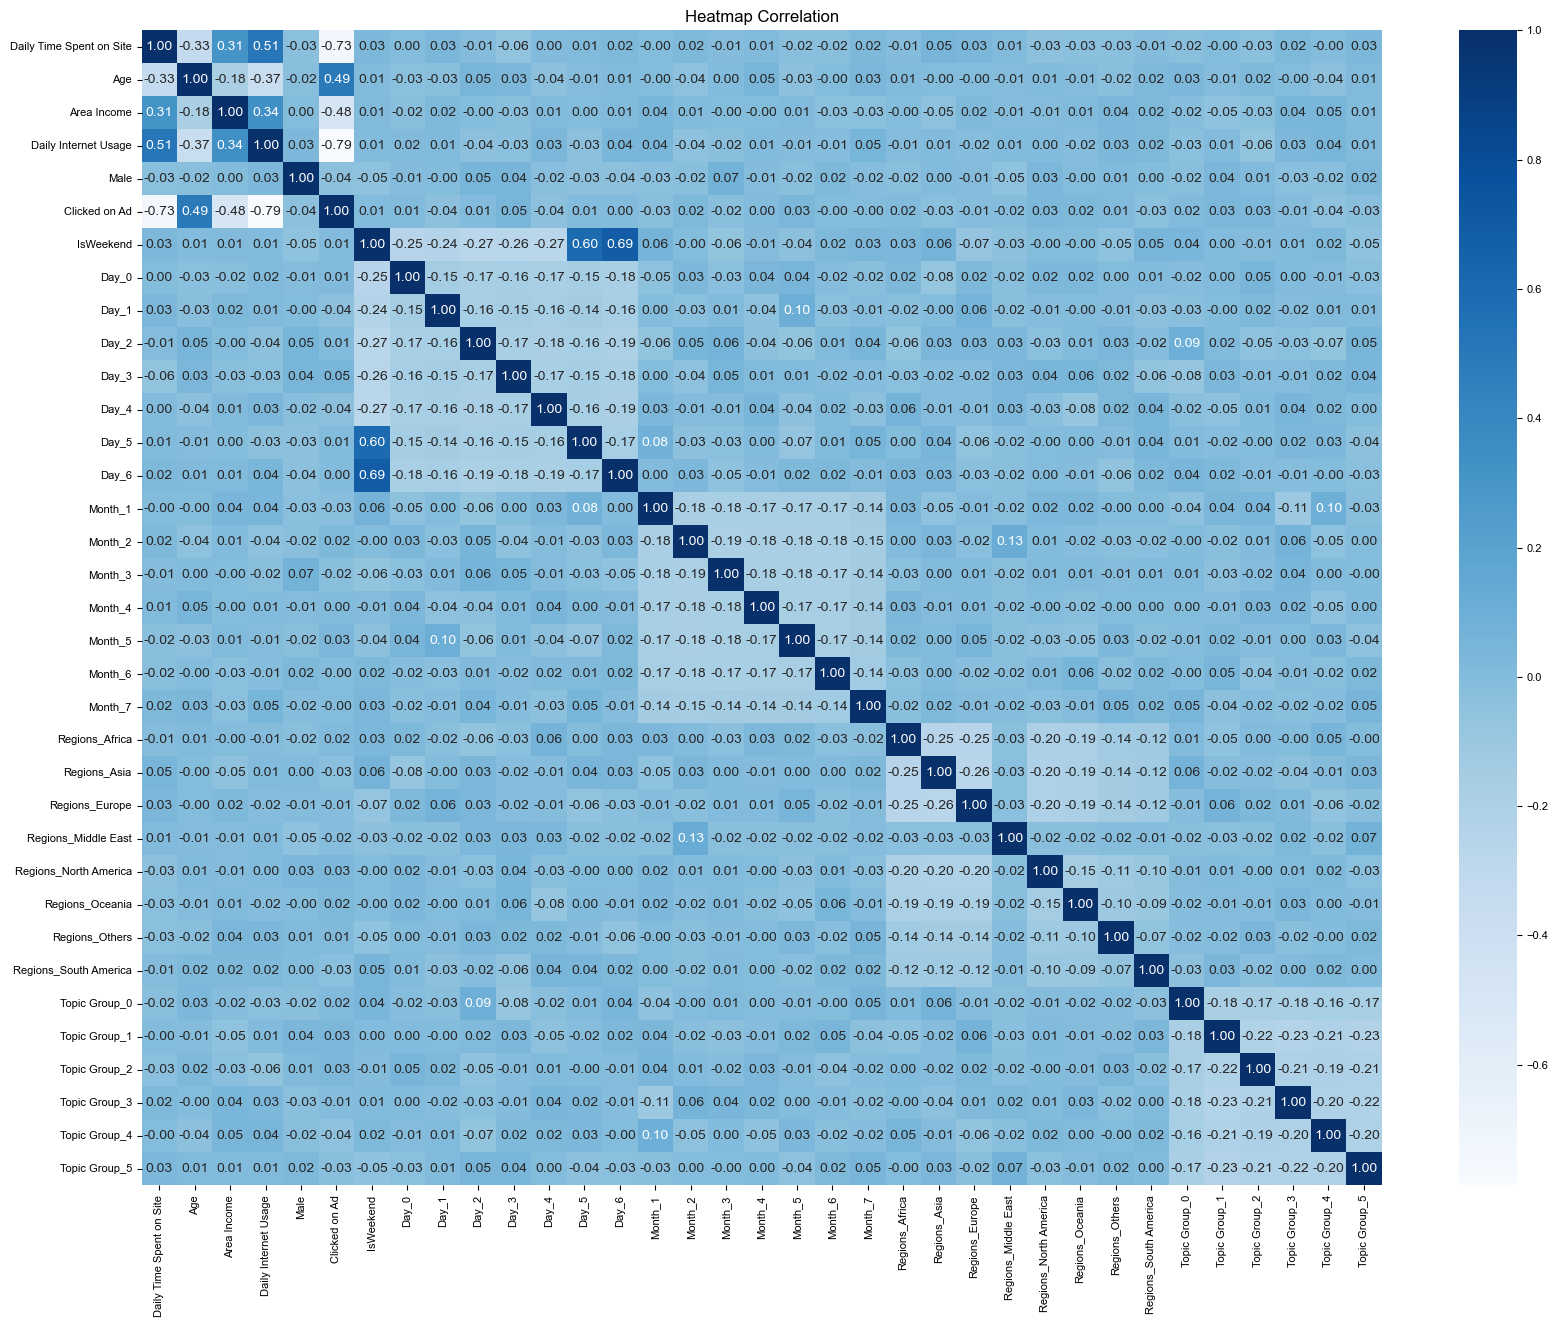

In [90]:
# Heatmap Correlation
plt.figure(figsize=(20,15))
sns.heatmap(df_encoded.corr(),annot=True, fmt='0.2f', cmap='Blues')
plt.title("Heatmap Correlation");

In [91]:
# VIF: All Columns
vif_init_selection = df_encoded.columns.drop(target)
vif_calculation(df_encoded, vif_init_selection)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1783: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,const,0.000000
1,Daily Time Spent on Site,1.453272
2,Age,1.216802
3,Area Income,1.184291
4,Daily Internet Usage,1.536628
5,Male,1.023121
6,IsWeekend,inf
7,Day_0,inf
8,Day_1,inf
9,Day_2,inf


In [92]:
# VIF: No Multicollinearity
vif_init_selection = ['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Male', 'Day_0',
       'Day_1', 'Day_2', 'Day_3', 'Day_4', 'Day_5', 'Month_1',
       'Month_2', 'Month_4', 'Month_5', 'Month_6', 'Month_7',
       'Regions_Africa', 'Regions_Asia', 'Regions_Europe',
       'Regions_Middle East', 'Regions_North America', 'Regions_Oceania', 'Regions_South America', 'Topic Group_0',
       'Topic Group_1', 'Topic Group_2', 'Topic Group_4',
       'Topic Group_5']
vif_calculation(df_encoded, vif_init_selection)

,Feature,VIF
0,const,106.762161
1,Daily Time Spent on Site,1.453272
2,Age,1.216802
3,Area Income,1.184291
4,Daily Internet Usage,1.536628
5,Male,1.023121
6,Day_0,1.640881
7,Day_1,1.578865
8,Day_2,1.722419
9,Day_3,1.674559


#### F. SAVE DATASET

In [94]:
# Final Dataset
final_df = df[['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Male', 'Clicked on Ad', 'Day', 'Month', 'IsWeekend',
       'Regions', 'Topic Group']].copy()

In [95]:
# Save Processed Data
os.chdir(data_exploration_path)
final_df.to_csv('eda_processed_data.csv')